In [22]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append('..')

import torch
from torch.distributions import Normal, MultivariateNormal

import matplotlib.pyplot as plt

from typing import Callable


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Old

In [23]:
def projection_onto_a_line(theta: torch.Tensor) -> Callable[[torch.Tensor, torch.Tensor], torch.Tensor]:
    """
    Creates a function that projects points onto a line.
    Args:
        theta: Angle tensor of any shape
    Returns:
        Function that takes x,y coordinates and projects them onto the line
    """

    def project(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        return x * torch.cos(theta) + y * torch.sin(theta)

    return project


def chebyshev_2(t: torch.Tensor) -> torch.Tensor:
    """
    Chebyshev polynomial of the 2nd degree.

    Args:
        t: Input tensor of any shape

    Returns:
        Tensor of same shape as input with Chebyshev polynomial applied
    """
    return 2 * t.pow(2) - 1


def klein_filter(theta_1: torch.Tensor, theta_2: torch.Tensor) -> Callable[[torch.Tensor, torch.Tensor], torch.Tensor]:
    """
    Klein filter for given angles theta_1 and theta_2.

    Args:
        theta_1: First angle tensor
        theta_2: Second angle tensor

    Returns:
        Function that takes x,y coordinates and applies the Klein filter
    """
    t = projection_onto_a_line(theta_1)

    def filter_fn(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        return torch.sin(theta_2) * t(x, y) + torch.cos(theta_2) * chebyshev_2(t(x,y))

    return filter_fn


def generate_klein_filter_matrix(
    theta_1: torch.Tensor, theta_2: torch.Tensor, size: int = 3, midpoint: bool = False, device: torch.device = None
) -> torch.Tensor:
    """
    Generate a Klein filter matrix of given size for specified angles.

    Args:
        theta_1: First angle tensor
        theta_2: Second angle tensor
        size: Size of the matrix
        midpoint: If True, use midpoints for the grid; otherwise, use edges
        device: PyTorch device to place tensors on. If None, uses theta_1's device

    Returns:
        Tensor of shape [size, size] containing the Klein filter values
    """
    if device is None:
        device = theta_1.device

    f = klein_filter(theta_1, theta_2)

    if midpoint:
        coords = torch.linspace(-1 + 1 / size, 1 - 1 / size, size, device=device)
    else:
        coords = torch.linspace(-1, 1, size, device=device)

    X, Y = torch.meshgrid(coords, coords, indexing="ij")
    return f(X, Y)


def generate_klein_filter_matrix_via_integration(
    theta_1: torch.Tensor, theta_2: torch.Tensor, size: int = 3, num_samples: int = 100, device: torch.device = None
) -> torch.Tensor:
    """
    Generate a Klein filter matrix using Monte Carlo integration.

    Args:
        theta_1: First angle tensor
        theta_2: Second angle tensor
        size: Size of the matrix
        num_samples: Number of random samples per cell for integration
        device: PyTorch device to place tensors on. If None, uses theta_1's device

    Returns:
        Tensor of shape [size, size] containing the integrated Klein filter values
    """
    if device is None:
        device = theta_1.device

    f = klein_filter(theta_1, theta_2)
    result = torch.zeros(size, size, device=device)

    for x in range(size):
        for y in range(size):
            xmin = -1.0 + ((2 * x) / (2 * size))
            xmax = -1.0 + ((2 * (x + 1.0)) / (2 * size))
            ymin = -1.0 + ((2 * y) / (2 * size))
            ymax = -1.0 + ((2 * (y + 1.0)) / (2 * size))

            # Generate random samples in the cell
            x_samples = torch.rand(num_samples, device=device) * (xmax - xmin) + xmin
            y_samples = torch.rand(num_samples, device=device) * (ymax - ymin) + ymin

            # Compute filter values and average
            filter_values = f(x_samples, y_samples)
            result[y, x] = filter_values.mean() * (xmax - xmin) * (ymax - ymin)

    return result


In [24]:
normal_dist = Normal(torch.tensor(0.0), torch.tensor(1.0))

In [25]:
theta_1, theta_2 = normal_dist.sample(sample_shape=torch.Size([1, 2])).chunk(2, dim=-1)
theta_1, theta_2 = theta_1 % torch.pi, theta_2 % 2 * torch.pi
print(theta_1, theta_2)

tensor([[1.1357]]) tensor([[5.5401]])


In [26]:
generate_klein_filter_matrix(theta_1, theta_2, size=3, midpoint=True, device=torch.device('cpu'))

tensor([[ 1.0177, -0.4300, -0.8011],
        [ 0.2109, -0.7364, -0.6071],
        [-0.3633, -0.8102, -0.1806]])

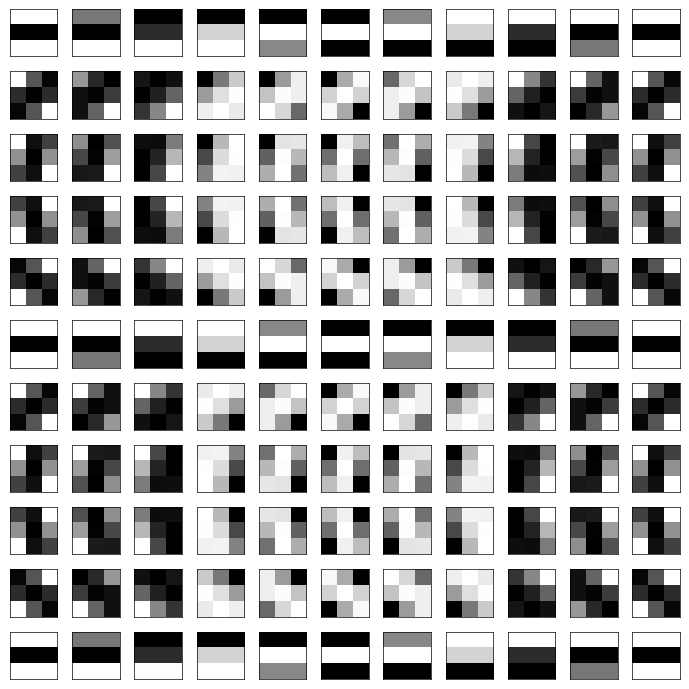

In [27]:
n = 10

fig, axes = plt.subplots(n+1, n+1, figsize=(7, 7))
for i in range(0, n+1):
    for j in range(0, n+1):
        theta_1 = torch.Tensor([2 * torch.pi * i / n])
        theta_2 = torch.Tensor([2 * torch.pi * j / n])
        filter_img = generate_klein_filter_matrix(theta_1, theta_2, size=3, midpoint=False)
        axes[i, j].imshow(filter_img.cpu().numpy(), cmap='gray', extent=[-1, 1, -1, 1])
        for spine in axes[i, j].spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(0.5)
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

plt.tight_layout()
plt.show()


In [28]:
num_samples = 100
thetas_1 = torch.rand(num_samples) * torch.pi
thetas_2 = torch.rand(num_samples) * 2 * torch.pi
klein_filters = torch.stack([generate_klein_filter_matrix(t1, t2, size=3, midpoint=False) for t1 in thetas_1 for t2 in thetas_2])
print(klein_filters.shape)

torch.Size([10000, 3, 3])


## Testing my code

In [29]:
from src.klein_normal import KleinNormal
#from src.utils import project_to_klein, project_to_torus, preimage_of_klein, preimage_of_torus_grid

### Batches

In [30]:
import torch
from torch.distributions import MultivariateNormal, constraints
from src.utils import project_to_klein, preimage_of_klein, preimage_of_torus_grid

class KleinConstraint(constraints.Constraint):
    def __init__(self):
        super().__init__()

    def check(self, value):
        # value is [..., 2] - now supports arbitrary batch dimensions
        theta1 = value[..., 0]
        theta2 = value[..., 1]
        return (theta1 >= 0) & (theta1 < torch.pi) & (theta2 >= 0) & (theta2 < 2 * torch.pi)

class BatchKleinNormal(MultivariateNormal):
    def __init__(self, loc, scale, grid_size: int = 3, validate_args=False):
        """
        loc:   Tensor of shape [..., 2] - supports batch dimensions
        scale: Tensor of shape [..., 2, 2] - covariance matrices for each batch
        """
        self.klein_support = KleinConstraint()
        self.grid_size = grid_size

        # Ensure proper batch dimensions
        if not isinstance(loc, torch.Tensor):
            loc = torch.tensor(loc)
        if not isinstance(scale, torch.Tensor):
            scale = torch.tensor(scale)
            
        # loc should be [..., 2]
        if loc.shape[-1] != 2:
            raise ValueError(f"loc must have last dimension 2, got {loc.shape}")
            
        # scale should be [..., 2, 2] 
        if scale.shape[-2:] != (2, 2):
            raise ValueError(f"scale must have last two dimensions (2, 2), got {scale.shape}")

        super().__init__(loc=loc, covariance_matrix=scale, validate_args=validate_args)

    def rsample(self, sample_shape=torch.Size()):
        # Sample from underlying normal distribution
        normal_samples = super().rsample(sample_shape)
        print(f"Normal samples shape: {normal_samples.shape}")
        
        # Ensure we have the right shape for Klein bottle (last dim should be 2)
        if normal_samples.shape[-1] != 2:
            raise ValueError(f"Expected last dimension to be 2, got {normal_samples.shape[-1]}")
        
        # Store original shape for later
        original_shape = normal_samples.shape
        
        # Flatten all dimensions except the last one (which should be 2)
        flat_samples = normal_samples.view(-1, 2)
        
        # Apply projection to Klein bottle - pass the entire tensor
        klein_samples = project_to_klein(flat_samples)
        print(f"Klein samples shape: {klein_samples.shape}")
        
        # Reshape back to original batch structure
        return klein_samples.view(original_shape)

    def log_prob(self, value, eps: float = 1e-6):
        # Ensure values are in the Klein support
        if not self.klein_support.check(value).all():
            raise ValueError("Value is not in the support of the Klein Normal distribution.")

        result_shape = value.shape[:-1]  # everything except the last dimension
        print(f"Value shape: {value.shape}")
        print(f"Result shape: {result_shape}")
        flat_values = value.view(-1, 2)

        # Generate all preimages on torus
        preimages_of_klein = preimage_of_klein(flat_values)  # shape [..., 2]
        print(f"Preimages of Klein shape: {preimages_of_klein.shape}")
        preimages_of_torus = preimage_of_torus_grid(preimages_of_klein, grid_size=self.grid_size)
        print(f"Preimages of Torus shape: {preimages_of_torus.shape}")
        # e.g. shape could be [..., K, 2], where K is # of torus preimages
        
        # Restore the sample and batch dimensions, but flatten the prelast dimension
        preimages = preimages_of_torus.view(*result_shape, -1, 2)
        #flat_preimages = preimages_of_torus.reshape(*result_shape, -1, 2)
        #original_shape = preimages_of_torus.shape[:-1]  # everything except the last
        #flat_preimages = preimages_of_torus.view(-1, preimages_of_torus.shape[-1])
        print(f"Preimages shape: {preimages.shape}")

        flat_preimages = preimages.view(-1, result_shape[-1], 2)
        print(f"Flattened preimages shape: {flat_preimages.shape}")
        
        # Log probabilities for each flattened preimage
        log_probs_all = super().log_prob(flat_preimages)
        print(f"Log probabilities shape: {log_probs_all.shape}")
        
        # Reshape back to [..., K], then sum-exp over the last dimension (the preimages)
        log_probs_all = log_probs_all.reshape(*result_shape, -1)
        print(f"Reshaped log probabilities shape: {log_probs_all.shape}")
        return torch.logsumexp(log_probs_all, dim=-1)

In [31]:
# Single distribution
loc = torch.zeros((1,2))
scale = torch.eye(2)
dist = KleinNormal(loc, scale)

# Batch of distributions  
batch_size = 16
loc_batch = torch.zeros(batch_size, 2)
scale_batch = torch.eye(2).expand(batch_size, 2, 2)
dist_batch = BatchKleinNormal(loc_batch, scale_batch)

# Sampling works with batches
samples = dist.rsample((100,))  # Shape: [100, 16, 2]
print(samples.shape)

log_probs = dist.log_prob(samples)  # Shape: [100, 16]

print(f"result: {log_probs.shape}")

torch.Size([100, 1, 2])
torch.Size([100, 1, 2])
Preimages of Klein: torch.Size([100, 2, 2]), Preimages of Torus: torch.Size([100, 98, 2])
result: torch.Size([100])


In [32]:
log_probs[:,0].shape

IndexError: too many indices for tensor of dimension 1

In [33]:
normal_on_klein = BatchKleinNormal(torch.Tensor([0,0]), torch.eye(2), grid_size=1)
sampled = normal_on_klein.rsample(torch.Size([10]))
print(sampled.shape)
normal_on_klein.log_prob(sampled)

Normal samples shape: torch.Size([10, 2])
Klein samples shape: torch.Size([10, 2])
torch.Size([10, 2])
Value shape: torch.Size([10, 2])
Result shape: torch.Size([10])
Preimages of Klein shape: torch.Size([10, 2, 2])
Preimages of Torus shape: torch.Size([10, 18, 2])
Preimages shape: torch.Size([10, 18, 2])
Flattened preimages shape: torch.Size([18, 10, 2])
Log probabilities shape: torch.Size([18, 10])
Reshaped log probabilities shape: torch.Size([10, 18])


tensor([-1.9281, -3.1305, -4.8645, -3.5461, -1.8405, -2.4785, -1.9096, -2.8260,
        -2.1623, -2.0167])

In [34]:
n_points = 100
x_range = torch.linspace(0, torch.pi, n_points)
y_range = torch.linspace(0, 2 * torch.pi, n_points)
X, Y = torch.meshgrid(x_range, y_range, indexing='ij')
grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1)  # (10000, 2)

print(grid_points.shape)

log_probs = normal_on_klein.log_prob(grid_points)  # (10000,)
print(log_probs.shape)
densities = torch.exp(log_probs)

# Reshape back to grid and integrate using trapezoidal rule
densities_grid = densities.reshape(n_points, n_points)
dx = x_range[1] - x_range[0]
dy = y_range[1] - y_range[0]

# 2D trapezoidal integration
integral = torch.trapz(torch.trapz(densities_grid, dx=dy, dim=1), dx=dx, dim=0)

print(f"Numerical integral: {integral.item():.6f}")
print(f"Should be close to 1.0")

# Alternative: simple Riemann sum
riemann_integral = torch.sum(densities) * dx * dy

#* Riemann sum -> 1 when n_points -> infty
print(f"Riemann sum: {riemann_integral.item():.6f}")

torch.Size([10000, 2])


ValueError: Value is not in the support of the Klein Normal distribution.

Shapes of points: torch.Size([2, 18, 2]), torch.Size([2, 2, 2]), torch.Size([2, 2])


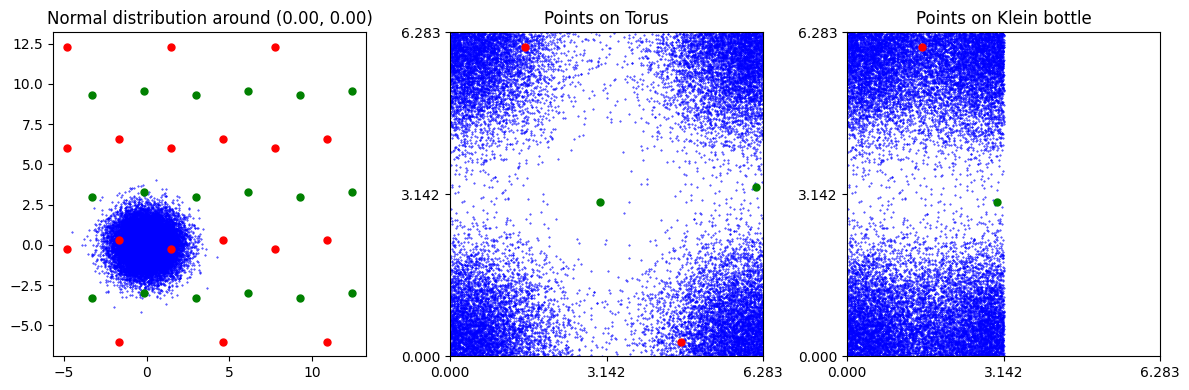

In [35]:
# Example usage

torch.random.manual_seed(28)

loc=torch.Tensor([0, 0])
scale = 1 #torch.Tensor([[1, 0], [0, 1]]) #* difference from numpy: in numpy cov is sigma^2, in pytorch it is sigma

points = torch.distributions.Normal(loc=loc, scale=scale).sample(sample_shape=torch.Size([20_000]))

klein_points = project_to_klein(points)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].plot(points[:,0], points[:,1], 'o', markersize=0.4, color='blue')
axes[0].set_title(f'Normal distribution around ({loc[0]:.2f}, {loc[1]:.2f})')


axes[1].plot(torch.remainder(points[:,0], 2 * torch.pi), torch.remainder(points[:,1], 2 * torch.pi), 'o', markersize=0.4, color='blue')
axes[1].set_title('Points on Torus')
axes[1].set_xlim(0, 2 * torch.pi)
axes[1].set_ylim(0, 2 * torch.pi)
axes[1].axes.get_xaxis().set_ticks([0, torch.pi, 2 * torch.pi])
axes[1].axes.get_yaxis().set_ticks([0, torch.pi, 2 * torch.pi])

axes[2].plot(klein_points[:,0], klein_points[:,1], 'o', markersize=0.4, color='blue')
axes[2].set_title('Points on Klein bottle')
axes[2].set_xlim(0, 2 * torch.pi)
axes[2].set_ylim(0, 2 * torch.pi)
axes[2].axes.get_xaxis().set_ticks([0, torch.pi, 2 * torch.pi])
axes[2].axes.get_yaxis().set_ticks([0, torch.pi, 2 * torch.pi])

# Choose a single point (e.g. the first one) to highlight
p_klein = torch.Tensor([[1.5, 6], [3,3]]) #sampled #torch.Tensor([3, 3]) #klein_points[28]#np.array([1.5, 6])
p_torus = preimage_of_klein(p_klein)
p_plane = preimage_of_torus_grid(p_torus) #preimage_of_torus_grid(p_torus) #preimage_of_torus_recursive(p_torus)

print(f"Shapes of points: {p_plane.shape}, {p_torus.shape}, {p_klein.shape}")

# Plot in red on each subplot
axes[0].plot(p_plane[0,:,0], p_plane[0,:,1], 'ro', markersize=5)
axes[0].plot(p_plane[1,:,0], p_plane[1,:,1], 'go', markersize=5)

axes[1].plot(p_torus[0,:,0], p_torus[0,:,1], 'ro', markersize=5)
axes[1].plot(p_torus[1,:,0], p_torus[1,:,1], 'go', markersize=5)

axes[2].plot(p_klein[0,0], p_klein[0,1], 'ro', markersize=5)
axes[2].plot(p_klein[1,0], p_klein[1,1], 'go', markersize=5)

plt.tight_layout()
plt.show()

## Multivariate Normal 

In [166]:
# Suppose we have batch_size = 16 and latent_dim = 20
batch_size = 16
latent_dim = 2

loc = torch.zeros(batch_size, latent_dim)
cov = torch.eye(latent_dim).unsqueeze(0).repeat(batch_size, 1, 1)
prior = MultivariateNormal(loc=loc, covariance_matrix=cov)